<a href="https://colab.research.google.com/github/memo124/Pr-ctica-de-Redes-Neuronales-Dise-o-de-Arquitecturas-Densas/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica de Redes Neuronales: Diseño de Arquitecturas Densas

## Integrantes

- Guillermo Andres Minero Alfaro
- Ruben Armando Vigil Mejia

En este cuaderno probamos tres redes neuronales y comparamos cuál funciona mejor con los mismos datos.

## 1. Preparación de los datos

Usaremos unos datos sobre cáncer de mama incluidos en Scikit-learn. La idea es distinguir entre dos posibles resultados. Separamos los datos en tres grupos: uno para que la red aprenda, otro para revisar cómo va y uno final para comprobar qué tan bien funciona con casos que no había visto.

In [1]:
%matplotlib inline

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Semillas para poder repetir el experimento.
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# Cargar el dataset.
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Separar primero el 20 % para la prueba final.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Separar una parte del entrenamiento para validación.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

# Ajustar el escalador solo con los datos de entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Dataset completo: {X.shape}')
print(f'Entrenamiento: {X_train_scaled.shape}')
print(f'Validación: {X_val_scaled.shape}')
print(f'Prueba: {X_test_scaled.shape}')

Dataset completo: (569, 30)
Entrenamiento: (364, 30)
Validación: (91, 30)
Prueba: (114, 30)


## 2. Modelo A: El Minimalista

Este es el modelo más sencillo. Tiene una sola capa oculta con 8 neuronas. ReLU ayuda a reconocer patrones y Sigmoid convierte el resultado final en una probabilidad entre 0 y 1. Lo usamos como nuestro punto de partida.

In [2]:
model_A = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_A.summary()
history_A = model_A.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=32, verbose=0
)
print('Modelo A entrenado correctamente.')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo A entrenado correctamente.


## 3. Modelo B: El Profundo

Este modelo tiene tres capas ocultas de 64, 128 y 64 neuronas. Puede encontrar más detalles que el Modelo A, pero también corre el riesgo de aprenderse de memoria los ejemplos en lugar de aprender una regla que funcione con datos nuevos. A eso se le llama overfitting.

In [3]:
model_B = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_B.summary()
history_B = model_B.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150, batch_size=32, verbose=0
)
print('Modelo B entrenado correctamente.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,625 (72.75 KB)

 Trainable params: 18,625 (72.75 KB)

 Non-trainable params: 0 (0.00 B)

Modelo B entrenado correctamente.


## 4. Curvas de aprendizaje

La línea roja marca el momento en que el error de validación (`val_loss`) fue más bajo. Si después la red mejora con los ejemplos de práctica, pero empeora con los de validación, significa que probablemente empezó a memorizar.

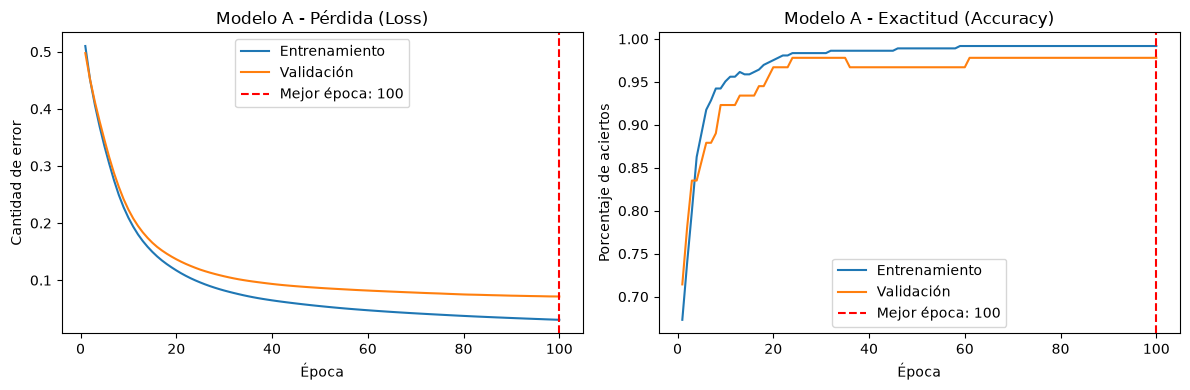

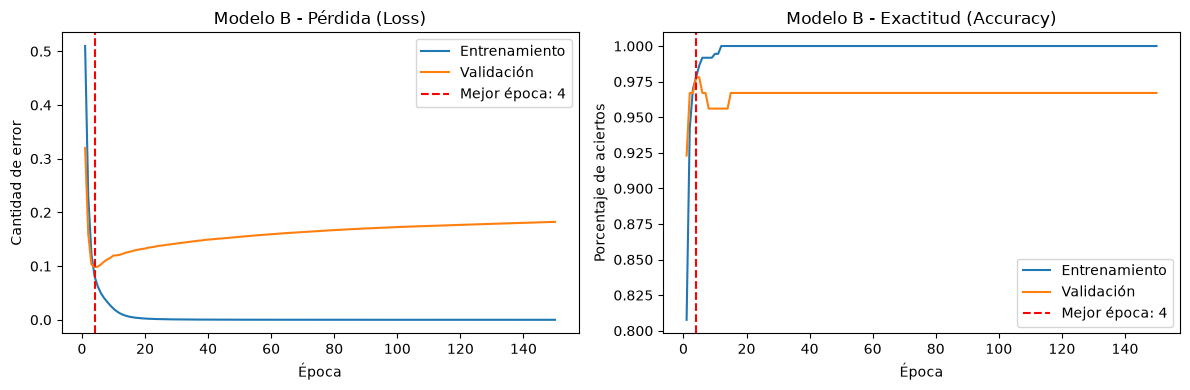

Mejor época del Modelo A según val_loss: 100
Mejor época del Modelo B según val_loss: 4


In [4]:
def plot_history(history, model_name):
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    epochs = range(1, len(history.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history.history['loss'], label='Entrenamiento')
    axes[0].plot(epochs, history.history['val_loss'], label='Validación')
    axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Mejor época: {best_epoch}')
    axes[0].set_title(f'{model_name} - Pérdida (Loss)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cantidad de error')
    axes[0].legend()

    axes[1].plot(epochs, history.history['accuracy'], label='Entrenamiento')
    axes[1].plot(epochs, history.history['val_accuracy'], label='Validación')
    axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Mejor época: {best_epoch}')
    axes[1].set_title(f'{model_name} - Exactitud (Accuracy)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Porcentaje de aciertos')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return best_epoch

best_epoch_A = plot_history(history_A, 'Modelo A')
best_epoch_B = plot_history(history_B, 'Modelo B')
print(f'Mejor época del Modelo A según val_loss: {best_epoch_A}')
print(f'Mejor época del Modelo B según val_loss: {best_epoch_B}')

## 5. Evaluación final de los modelos A y B

Ahora usamos por primera vez los datos de prueba. Es como un examen final: estos casos no se usaron para entrenar ni para escoger la mejor época.

In [5]:
test_loss_A, test_accuracy_A = model_A.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_B, test_accuracy_B = model_B.evaluate(X_test_scaled, y_test, verbose=0)

results = pd.DataFrame({
    'Modelo': ['A - Minimalista', 'B - Profundo'],
    'Mejor época (val_loss)': [best_epoch_A, best_epoch_B],
    'Error en prueba': [test_loss_A, test_loss_B],
    'Aciertos en prueba': [test_accuracy_A, test_accuracy_B]
})
display(results.round(4))

,Modelo,Mejor época (val_loss),Error en prueba,Aciertos en prueba
0,A - Minimalista,100,0.0861,0.9561
1,B - Profundo,4,0.2042,0.9561


## 6. Análisis de overfitting

In [6]:
winner = 'Modelo A' if test_accuracy_A >= test_accuracy_B else 'Modelo B'
analysis = f'''
- El **Modelo A** tuvo su menor error de validación en la época **{best_epoch_A}**. Sus curvas se mantienen bastante cercanas.
- El **Modelo B** tuvo su menor error de validación en la época **{best_epoch_B}**. Después, siguió mejorando con los datos de práctica, pero empeoró con los datos de validación. Esa es una señal clara de overfitting.
- Esto sucede porque el Modelo B es grande para un grupo de datos pequeño y puede aprenderse los ejemplos de memoria.
- En el examen final, el Modelo A acertó **{test_accuracy_A:.2%}** y el Modelo B **{test_accuracy_B:.2%}** de los casos.
- En esta ejecución, **{winner}** consiguió más aciertos. Aun así, también debemos observar las gráficas y no quedarnos solamente con un número.

No usamos EarlyStopping en estos dos modelos porque queríamos ver claramente cuándo comenzaban a memorizar. Lo usaremos en el Modelo C para detenerlo a tiempo.
'''
display(Markdown(analysis))


- El **Modelo A** tuvo su menor error de validación en la época **100**. Sus curvas se mantienen bastante cercanas.
- El **Modelo B** tuvo su menor error de validación en la época **4**. Después, siguió mejorando con los datos de práctica, pero empeoró con los datos de validación. Esa es una señal clara de overfitting.
- Esto sucede porque el Modelo B es grande para un grupo de datos pequeño y puede aprenderse los ejemplos de memoria.
- En el examen final, el Modelo A acertó **95.61%** y el Modelo B **95.61%** de los casos.
- En esta ejecución, **Modelo A** consiguió más aciertos. Aun así, también debemos observar las gráficas y no quedarnos solamente con un número.

No usamos EarlyStopping en estos dos modelos porque queríamos ver claramente cuándo comenzaban a memorizar. Lo usaremos en el Modelo C para detenerlo a tiempo.


---
## 7. Modelo C: El Optimizado

El Modelo C busca aprender bien sin memorizar. **Dropout** apaga algunas neuronas al azar mientras practica, y **L2** evita que una sola conexión tenga demasiada importancia. Adam ayuda a ajustar la red y EarlyStopping detiene el entrenamiento cuando el resultado de validación ya no mejora.

In [7]:
model_C = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.30),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.30),
    Dense(1, activation='sigmoid')
])

model_C.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_C.summary()
history_C = model_C.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)
print(f'Modelo C entrenado en {len(history_C.history["loss"])} épocas.')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Modelo C entrenado en 41 épocas.


## 8. Curvas del Modelo C

Usamos las mismas gráficas para ver si el modelo mejora de forma parecida durante la práctica y la validación. EarlyStopping regresa al punto donde el modelo había conseguido su mejor resultado.

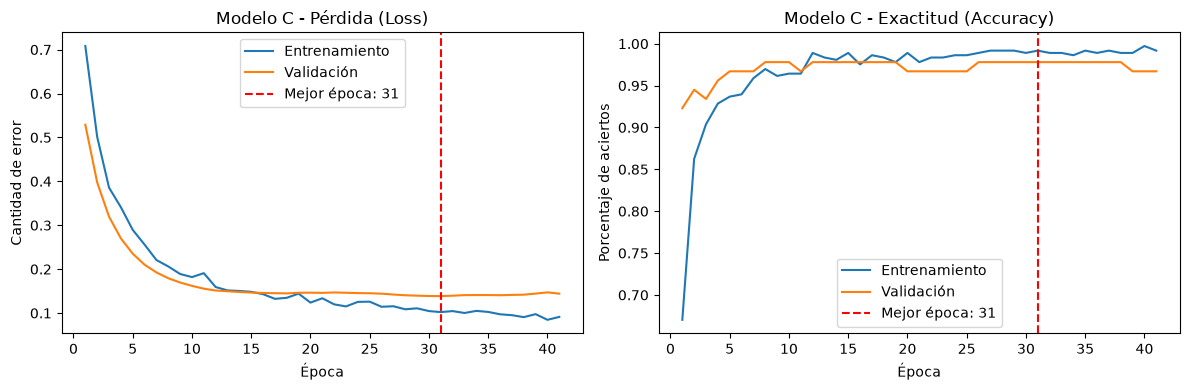

Mejor época del Modelo C según val_loss: 31
EarlyStopping detuvo el entrenamiento después de 41 épocas.


In [8]:
best_epoch_C = plot_history(history_C, 'Modelo C')
epochs_C = len(history_C.history['loss'])
print(f'Mejor época del Modelo C según val_loss: {best_epoch_C}')
print(f'EarlyStopping detuvo el entrenamiento después de {epochs_C} épocas.')

## 9. Comparación final de los tres modelos

In [9]:
test_loss_C, test_accuracy_C = model_C.evaluate(X_test_scaled, y_test, verbose=0)

final_results = pd.DataFrame({
    'Modelo': ['A - Minimalista', 'B - Profundo', 'C - Optimizado'],
    'Épocas entrenadas': [len(history_A.history['loss']), len(history_B.history['loss']), epochs_C],
    'Mejor época (val_loss)': [best_epoch_A, best_epoch_B, best_epoch_C],
    'Error en prueba': [test_loss_A, test_loss_B, test_loss_C],
    'Aciertos en prueba': [test_accuracy_A, test_accuracy_B, test_accuracy_C]
})
display(final_results.round(4))

,Modelo,Épocas entrenadas,Mejor época (val_loss),Error en prueba,Aciertos en prueba
0,A - Minimalista,100,100,0.0861,0.9561
1,B - Profundo,150,4,0.2042,0.9561
2,C - Optimizado,41,31,0.1572,0.9737


## 10. Mesa de auditoría y conclusiones

In [10]:
max_accuracy = final_results['Aciertos en prueba'].max()
top_models = final_results[np.isclose(final_results['Aciertos en prueba'], max_accuracy)]
best_model = top_models.loc[top_models['Error en prueba'].idxmin()]

if len(top_models) > 1:
    tied_names = ' y '.join(top_models['Modelo'])
    winner_text = (
        f'{tied_names} empataron con el mayor porcentaje de aciertos. ' 
        f'Como desempate, {best_model["Modelo"]} tuvo menos error.'
    )
else:
    winner_text = f'{best_model["Modelo"]} obtuvo el mayor porcentaje de aciertos.'

final_analysis = f'''
### Lo que aprendimos

1. **ReLU y Sigmoid:** ReLU ayuda a las capas internas a encontrar patrones útiles. Al final, Sigmoid convierte el resultado en una probabilidad entre 0 y 1, algo parecido a decir qué tan segura está la red de su respuesta.
2. **Overfitting:** El Modelo A se comportó de manera estable. El Modelo B comenzó a memorizar aproximadamente después de la época **{best_epoch_B}**: mejoraba con los ejercicios conocidos, pero empeoraba cuando veía los datos de validación.
3. **Dropout y L2:** Ayudaron al Modelo C a no depender demasiado de las mismas neuronas o conexiones. Su mejor resultado de validación apareció en la época **{best_epoch_C}**.
4. **EarlyStopping:** Detuvo el Modelo C después de **{epochs_C} épocas** y regresó a su mejor momento. Es parecido a dejar de estudiar cuando seguir practicando ya no mejora el resultado.
5. **Examen final:** A acertó **{test_accuracy_A:.2%}**, B acertó **{test_accuracy_B:.2%}** y C acertó **{test_accuracy_C:.2%}** de los casos.
6. **Modelo ganador:** {winner_text}

La conclusión más importante es que una red más grande no siempre aprende mejor. También importa que funcione bien con ejemplos nuevos y que no se limite a memorizar los ejercicios de práctica.
'''
display(Markdown(final_analysis))


### Lo que aprendimos

1. **ReLU y Sigmoid:** ReLU ayuda a las capas internas a encontrar patrones útiles. Al final, Sigmoid convierte el resultado en una probabilidad entre 0 y 1, algo parecido a decir qué tan segura está la red de su respuesta.
2. **Overfitting:** El Modelo A se comportó de manera estable. El Modelo B comenzó a memorizar aproximadamente después de la época **4**: mejoraba con los ejercicios conocidos, pero empeoraba cuando veía los datos de validación.
3. **Dropout y L2:** Ayudaron al Modelo C a no depender demasiado de las mismas neuronas o conexiones. Su mejor resultado de validación apareció en la época **31**.
4. **EarlyStopping:** Detuvo el Modelo C después de **41 épocas** y regresó a su mejor momento. Es parecido a dejar de estudiar cuando seguir practicando ya no mejora el resultado.
5. **Examen final:** A acertó **95.61%**, B acertó **95.61%** y C acertó **97.37%** de los casos.
6. **Modelo ganador:** C - Optimizado obtuvo el mayor porcentaje de aciertos.

La conclusión más importante es que una red más grande no siempre aprende mejor. También importa que funcione bien con ejemplos nuevos y que no se limite a memorizar los ejercicios de práctica.
